<a href="https://colab.research.google.com/github/Rakhshindaa/Text-to-Image-generator/blob/main/Text_to_Image_generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Installing diffusers library
!pip install diffusers transformers accelerate safetensors torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 38.4 MB/s eta 0:00:00


In [4]:
# Importing StableDiffusionPipeline to use pre-trained Stable Diffusion models
from diffusers import StableDiffusionXLPipeline
# Image is a class for the PIL module to visualize images in a Python Notebook
from PIL import Image
# Importing PyTorch library, for building and training neural networks
import torch

In [5]:
# Loading SDXL 1.0 model
model_id = "stabilityai/stable-diffusion-xl-base-1.0"
device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
# Creating the pipeline and moving pipeline to the appropriate device
pipeline = StableDiffusionXLPipeline.from_pretrained(model_id,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    use_safetensors=True).to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/575 [00:00<?, ?B/s]

...

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/10.3G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

vae_1_0/diffusion_pytorch_model.safetens(…):   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [2]:
# Defining function for the creation of a grid of images
def image_grid(imgs, rows, cols):
    assert len(imgs) == rows*cols
    w, h = imgs[0].size
    grid = Image.new('RGB', size = (cols*w,rows * w))
    grid_w, grid_h = grid.size
    for i, img in enumerate(imgs):
        grid.paste(img, box = ((i%cols)*w, (i // cols)*h))
    return grid

Welcome to Text-To-Image generator...
Enter the prompt to generate the images:
feel the nature
Enter the number of images to be generated:
1


  0%|          | 0/50 [00:00<?, ?it/s]

Here is your output:


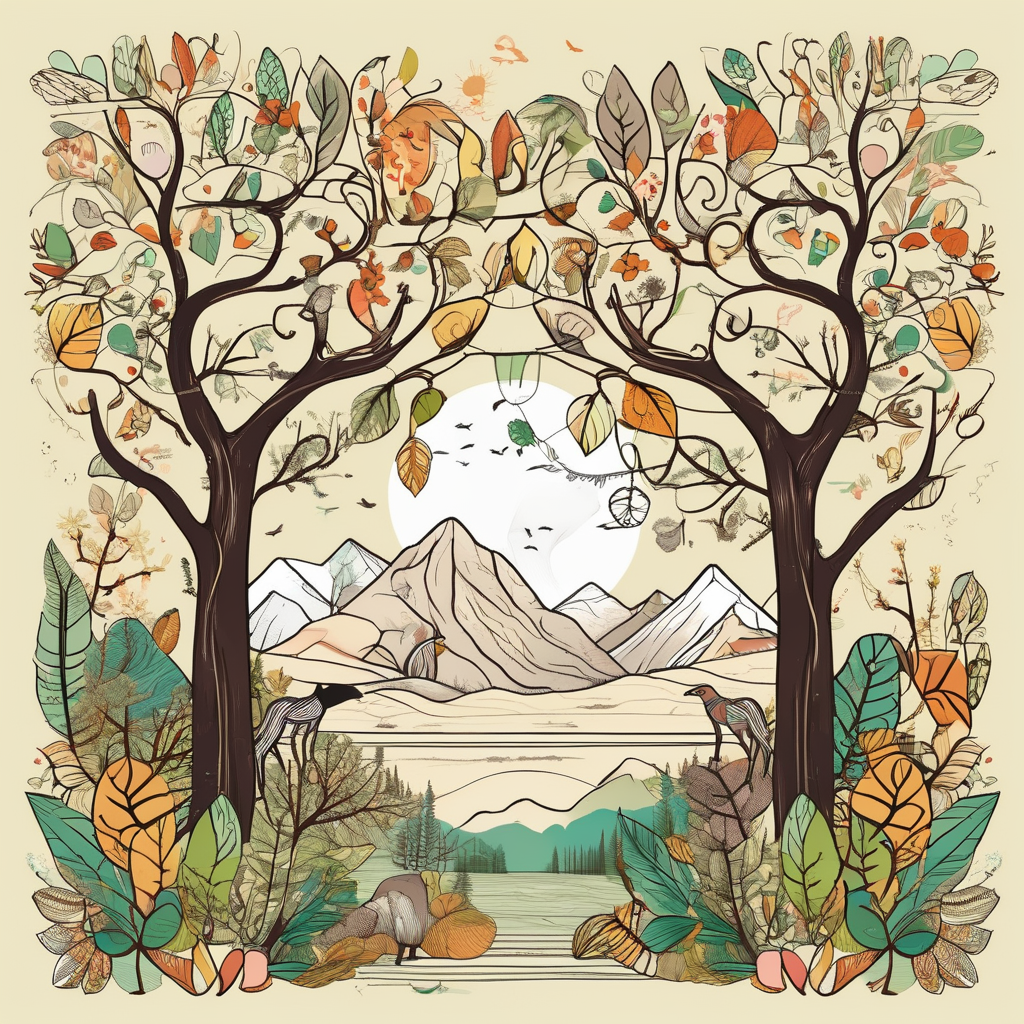

If you want to continue, PRESS 1
 If you want to exit, PRESS 0
1
Enter the prompt to generate the images:
bts
Enter the number of images to be generated:
1


  0%|          | 0/50 [00:00<?, ?it/s]

Here is your output:


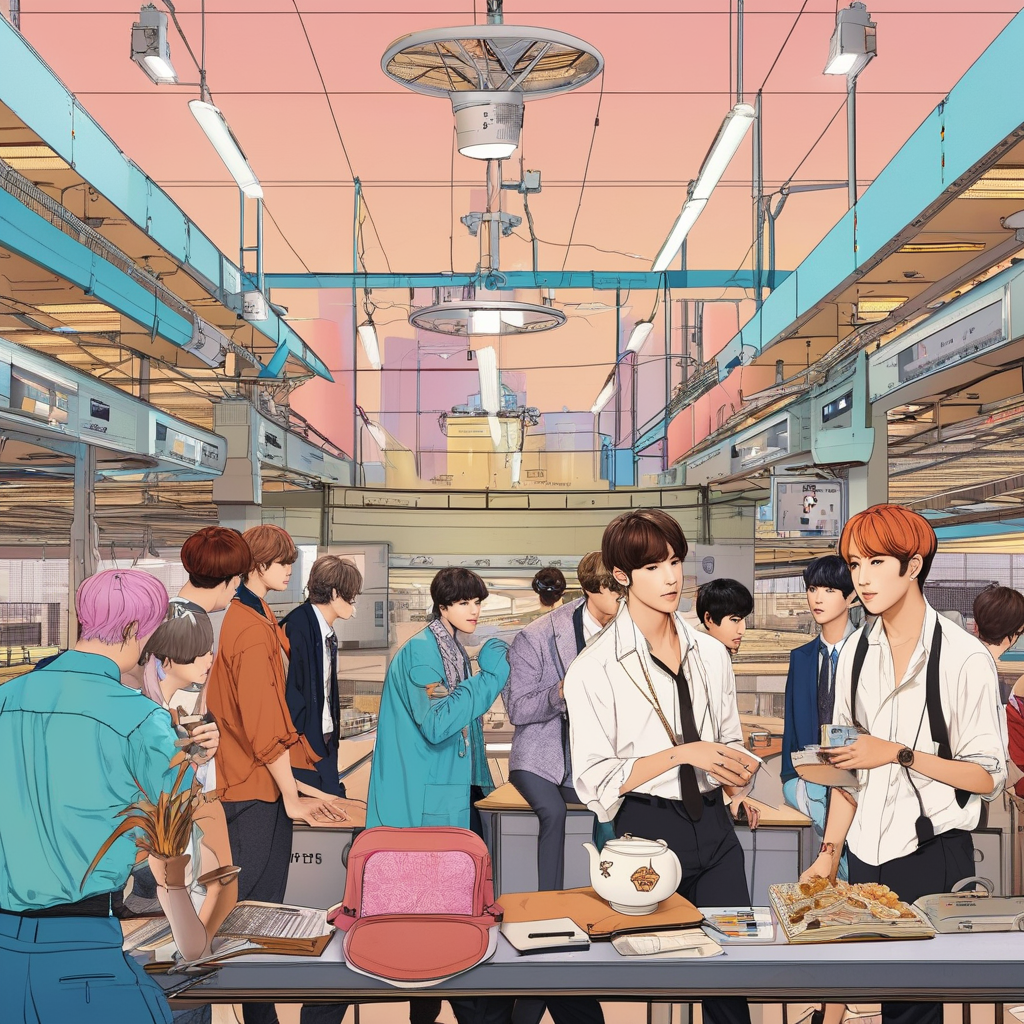

If you want to continue, PRESS 1
 If you want to exit, PRESS 0
Rakhshinda Nausheen
Invalid input. Please enter 1 or 0.
1
Enter the prompt to generate the images:
Rakhshinda Nausheen
Enter the number of images to be generated:
1


  0%|          | 0/50 [00:00<?, ?it/s]

Here is your output:


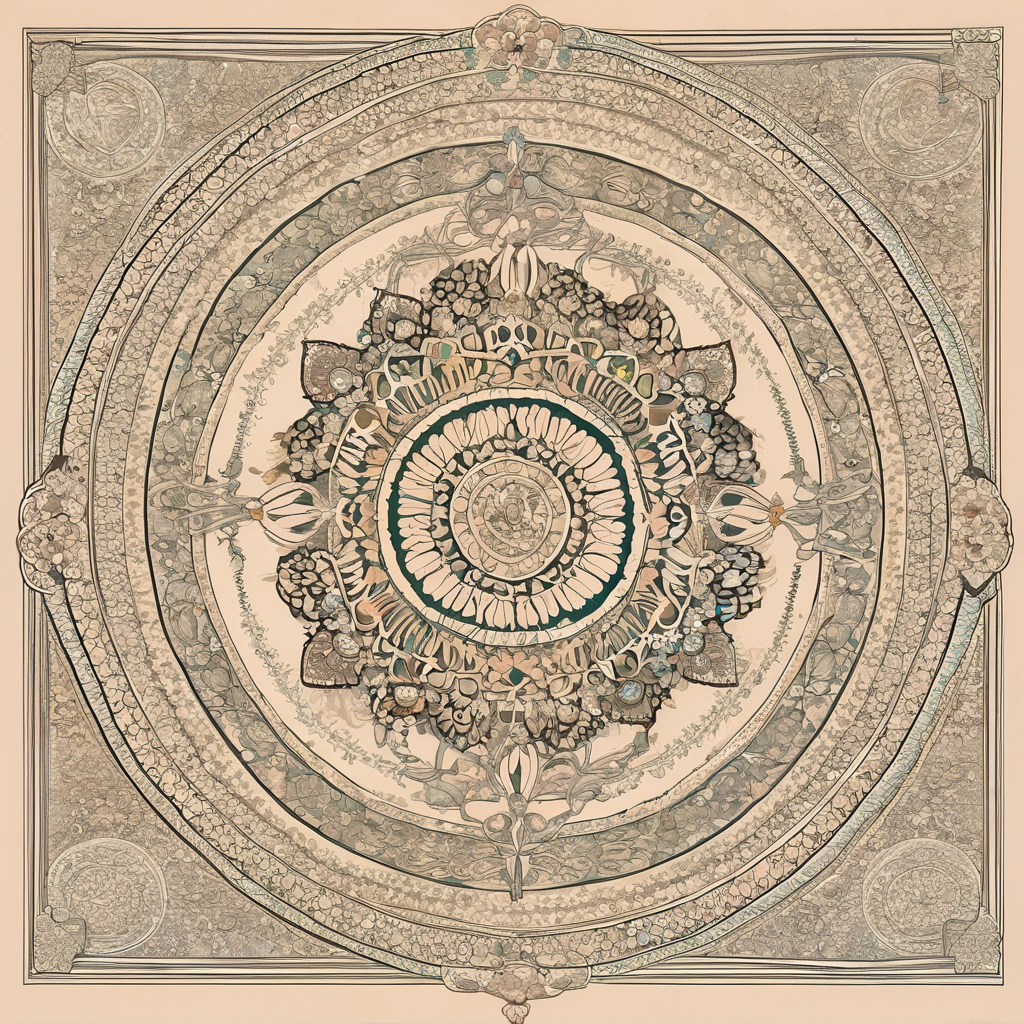

If you want to continue, PRESS 1
 If you want to exit, PRESS 0
0
Thank you !!!


In [7]:
print("Welcome to Text-To-Image generator...")
flag=1
while(flag==1):
  print("Enter the prompt to generate the images:")
  prompt=input()
  print("Enter the number of images to be generated:")
  n_images=int(input())
  prompt=[prompt]*n_images
  images = pipeline(prompt=prompt,
    negative_prompt=["blurry, low quality, deformed, distorted, out of frame"] * n_images,
    num_inference_steps=50,
    guidance_scale=10.0,).images
  c = int(n_images**0.5)
  r = (n_images + c- 1)//c
  grid = image_grid(images,rows=r,cols=c)
  print("Here is your output:")
  display(grid)
  print("If you want to continue, PRESS 1\n If you want to exit, PRESS 0")
  while True: # Handling invalid input
    try:
      flag=int(input())
      break  # Exit the loop if input is valid
    except ValueError:
      print("Invalid input. Please enter 1 or 0.")
print("Thank you !!!")